In [1]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)
random.seed(42) 
n = 50

male_names = [
    'Vineet', 'Amit', 'Vikram', 'Karan', 'Rahul',
    'Suresh', 'Ravi', 'Ankit', 'Varun', 'Manish',
    'Deepak', 'Sanjay', 'Nikhil'
]

female_names = [
    'Priya', 'Sunidhi', 'Kriti', 'Pooja', 'Neha',
    'Sunita', 'Divya', 'Shreya', 'Kavya', 'Meera',
    'Nisha', 'Simran', 'Ritika', 'Tanvi', 'Komal', 'Ananya'
]

names = []
genders = []
for _ in range(n):
    gender = random.choice(['Male', 'Female'])
    
    if gender == 'Male':
        name = random.choice(male_names)
    else:
        name = random.choice(female_names)

    names.append(name)
    genders.append(gender)

df = pd.DataFrame({
   'name': names,
    'gender': genders,
    'age': np.random.randint(21, 65, n),                     #Very young or near retirement → higher risk , Middle working age → lower risk    
    'income': np.random.randint(20000, 200000, n),           #Higher income → Lower default risk , Lower income → Higher default risk    
    'credit_score': np.random.randint(300, 850, n),          #strongest predictor of default    
    'employment_years': np.random.randint(0, 30, n),         #0–1 years → High risk , 5–10 years → Low risk    
    'existing_loans': np.random.randint(0, 5, n),            #Higher debt → Higher default risk   
    'loan_amount': np.random.randint( 100000,1000000 ,n),      #Large loans with less income increase risk.    
    'property_area': np.random.choice(['Urban', 'Rural', 'Semiurban'], n),  # Used to estimate employment and income stability
    
})

df.loc[np.random.choice(n, 15), 'credit_score'] = np.nan
df.loc[np.random.choice(n, 20), 'income'] = np.nan
df.loc[np.random.choice(n, 25), 'employment_years'] = np.nan
df.index = range(1, n+1)
print(df.shape)
df.head(50)

(50, 9)


,name,gender,age,income,credit_score,employment_years,existing_loans,loan_amount,property_area
1,Vineet,Male,59,NaN,530.0,18.0,4,898615,Semiurban
2,Shreya,Female,49,NaN,NaN,9.0,3,522515,Semiurban
3,Vikram,Male,35,144358.0,327.0,11.0,1,768234,Rural
4,Deepak,Male,63,68555.0,434.0,NaN,2,478480,Urban
5,Manish,Male,28,37159.0,500.0,NaN,0,132711,Rural
6,Sunidhi,Female,41,130510.0,332.0,NaN,0,891971,Urban
7,Amit,Male,59,NaN,347.0,21.0,3,601157,Semiurban
8,Karan,Male,39,NaN,802.0,NaN,2,284423,Urban
9,Varun,Male,43,55920.0,NaN,8.0,4,616349,Urban
10,Sanjay,Male,31,39457.0,398.0,19.0,2,803714,Urban


In [2]:
#basic eda on dataset to understand it.

print("first 5 rows :\n",df.head())
print("\nbottom 5 rows :\n",df.tail())
print("\nshape/dimension of dataset :\n",df.shape)
print("\nstructural info :\n")
df.info()
print("\nstatistical info :\n",df.describe())

first 5 rows :
      name  gender  age    income  credit_score  employment_years  \
1  Vineet    Male   59       NaN         530.0              18.0   
2  Shreya  Female   49       NaN           NaN               9.0   
3  Vikram    Male   35  144358.0         327.0              11.0   
4  Deepak    Male   63   68555.0         434.0               NaN   
5  Manish    Male   28   37159.0         500.0               NaN   

   existing_loans  loan_amount property_area  
1               4       898615     Semiurban  
2               3       522515     Semiurban  
3               1       768234         Rural  
4               2       478480         Urban  
5               0       132711         Rural  

bottom 5 rows :
       name  gender  age    income  credit_score  employment_years  \
46  Ritika  Female   29       NaN         658.0              10.0   
47    Neha  Female   46  149312.0         755.0               NaN   
48    Neha  Female   22   32666.0           NaN              26.0   

In [3]:
#finding null values
print(df.isnull().sum())

name                 0
gender               0
age                  0
income              19
credit_score        13
employment_years    21
existing_loans       0
loan_amount          0
property_area        0
dtype: int64


In [4]:
#handling null values
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['income'] = df['income'].fillna(df['income'].median())
df['employment_years'] = df['employment_years'].fillna(df['employment_years'].median())
print(df)

       name  gender  age    income  credit_score  employment_years  \
1    Vineet    Male   59  102798.0         530.0              18.0   
2    Shreya  Female   49  102798.0         542.0               9.0   
3    Vikram    Male   35  144358.0         327.0              11.0   
4    Deepak    Male   63   68555.0         434.0              16.0   
5    Manish    Male   28   37159.0         500.0              16.0   
6   Sunidhi  Female   41  130510.0         332.0              16.0   
7      Amit    Male   59  102798.0         347.0              21.0   
8     Karan    Male   39  102798.0         802.0              16.0   
9     Varun    Male   43   55920.0         542.0               8.0   
10   Sanjay    Male   31   39457.0         398.0              19.0   
11   Shreya  Female   31   98953.0         846.0              16.0   
12    Kavya  Female   44  102798.0         761.0              29.0   
13   Nikhil    Male   56  102798.0         304.0              16.0   
14   Sanjay    Male 

In [5]:
df['gender'].value_counts()

gender
Female    26
Male      24
Name: count, dtype: int64

In [6]:
df['property_area'].value_counts()

property_area
Urban        19
Semiurban    17
Rural        14
Name: count, dtype: int64

In [7]:
# LabelEncoder for catagorical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['property_area'] = le.fit_transform(df['property_area'])
print(df)

       name  gender  age    income  credit_score  employment_years  \
1    Vineet       1   59  102798.0         530.0              18.0   
2    Shreya       0   49  102798.0         542.0               9.0   
3    Vikram       1   35  144358.0         327.0              11.0   
4    Deepak       1   63   68555.0         434.0              16.0   
5    Manish       1   28   37159.0         500.0              16.0   
6   Sunidhi       0   41  130510.0         332.0              16.0   
7      Amit       1   59  102798.0         347.0              21.0   
8     Karan       1   39  102798.0         802.0              16.0   
9     Varun       1   43   55920.0         542.0               8.0   
10   Sanjay       1   31   39457.0         398.0              19.0   
11   Shreya       0   31   98953.0         846.0              16.0   
12    Kavya       0   44  102798.0         761.0              29.0   
13   Nikhil       1   56  102798.0         304.0              16.0   
14   Sanjay       1 

In [8]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(outliers)

Empty DataFrame
Columns: [name, gender, age, income, credit_score, employment_years, existing_loans, loan_amount, property_area]
Index: []


In [10]:
outliers = df[(df['employment_years'] < lower_bound) | (df['employment_years'] > upper_bound)]

print(outliers)

      name  gender  age    income  credit_score  employment_years  \
19    Ravi       1   44   31534.0         314.0               1.0   
20  Suresh       1   64  102798.0         760.0               2.0   
28  Nikhil       1   64  102798.0         335.0               1.0   
29   Kriti       0   45   32185.0         542.0               1.0   
34   Divya       0   35  102798.0         639.0               0.0   
38  Ritika       0   27  140151.0         772.0               1.0   

    existing_loans  loan_amount  property_area  
19               3       177505              0  
20               3       102869              1  
28               0       909760              1  
29               1       977844              2  
34               0       539430              2  
38               1       356687              0  


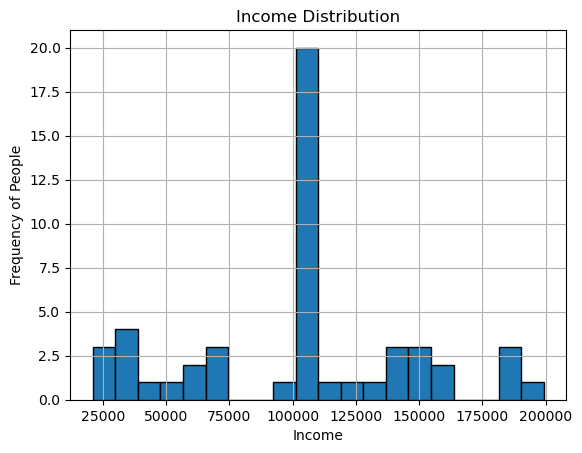

In [14]:
import matplotlib.pyplot as plt
df['income'].hist(bins=20, edgecolor='black')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency of People')
plt.show()

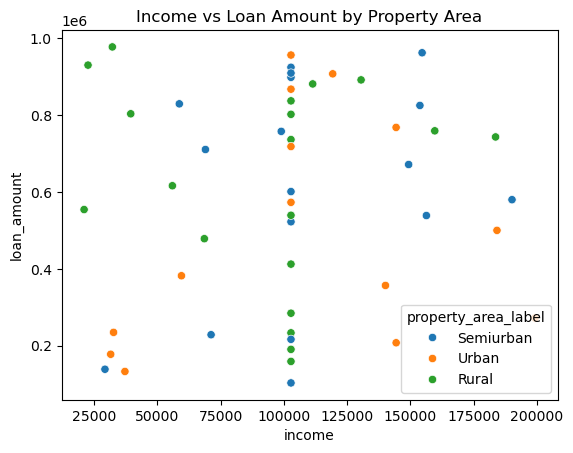

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
df['property_area_label'] = df['property_area'].map({0:'Urban', 1:'Semiurban', 2:'Rural'})
sns.scatterplot(x='income', y='loan_amount', data=df, hue='property_area_label')
plt.title('Income vs Loan Amount by Property Area')
plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler

cols = ['income', 'employment_years','credit_score']
scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])
print(df[cols])

      income  employment_years  credit_score
1   0.458815          0.620690      0.416974
2   0.458815          0.310345      0.439114
3   0.691976          0.379310      0.042435
4   0.266704          0.551724      0.239852
5   0.090566          0.551724      0.361624
6   0.614286          0.551724      0.051661
7   0.458815          0.724138      0.079336
8   0.458815          0.551724      0.918819
9   0.195819          0.275862      0.439114
10  0.103458          0.655172      0.173432
11  0.437244          0.551724      1.000000
12  0.458815          1.000000      0.843173
13  0.458815          0.551724      0.000000
14  0.458815          0.862069      0.392989
15  0.458815          0.551724      0.918819
16  0.458815          0.551724      0.725092
17  0.551390          1.000000      0.439114
18  0.912570          0.206897      0.372694
19  0.059008          0.034483      0.018450
20  0.458815          0.068966      0.841328
21  0.507002          0.551724      0.435424
22  0.0000

In [30]:
print(df)

       name  gender  age    income  credit_score  employment_years  \
1    Vineet       1   59  0.458815      0.416974          0.620690   
2    Shreya       0   49  0.458815      0.439114          0.310345   
3    Vikram       1   35  0.691976      0.042435          0.379310   
4    Deepak       1   63  0.266704      0.239852          0.551724   
5    Manish       1   28  0.090566      0.361624          0.551724   
6   Sunidhi       0   41  0.614286      0.051661          0.551724   
7      Amit       1   59  0.458815      0.079336          0.724138   
8     Karan       1   39  0.458815      0.918819          0.551724   
9     Varun       1   43  0.195819      0.439114          0.275862   
10   Sanjay       1   31  0.103458      0.173432          0.655172   
11   Shreya       0   31  0.437244      1.000000          0.551724   
12    Kavya       0   44  0.458815      0.843173          1.000000   
13   Nikhil       1   56  0.458815      0.000000          0.551724   
14   Sanjay       1 

In [32]:
print(df)

       name  gender  age    income  credit_score  employment_years  \
1    Vineet       1   59  0.458815      0.416974          0.620690   
2    Shreya       0   49  0.458815      0.439114          0.310345   
3    Vikram       1   35  0.691976      0.042435          0.379310   
4    Deepak       1   63  0.266704      0.239852          0.551724   
5    Manish       1   28  0.090566      0.361624          0.551724   
6   Sunidhi       0   41  0.614286      0.051661          0.551724   
7      Amit       1   59  0.458815      0.079336          0.724138   
8     Karan       1   39  0.458815      0.918819          0.551724   
9     Varun       1   43  0.195819      0.439114          0.275862   
10   Sanjay       1   31  0.103458      0.173432          0.655172   
11   Shreya       0   31  0.437244      1.000000          0.551724   
12    Kavya       0   44  0.458815      0.843173          1.000000   
13   Nikhil       1   56  0.458815      0.000000          0.551724   
14   Sanjay       1 